# Clinical Trial Data Analytics

## Objective

Analyze heart failure clinical records to identify factors associated with mortality and patient outcomes.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("../DATA/heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

Shape: (299, 13)

Columns:
Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='str')


## Dataset Overview

The dataset contains demographic and clinical information for heart failure patients, including laboratory values and survival outcomes.

## Patient Demographics Analysis

This section analyzes the demographic characteristics of patients including age distribution and gender composition.

In [6]:
print("Total Patients:", len(df))
print("Average Age:", round(df["age"].mean(), 2))
print("Minimum Age:", df["age"].min())
print("Maximum Age:", df["age"].max())

Total Patients: 299
Average Age: 60.83
Minimum Age: 40.0
Maximum Age: 95.0


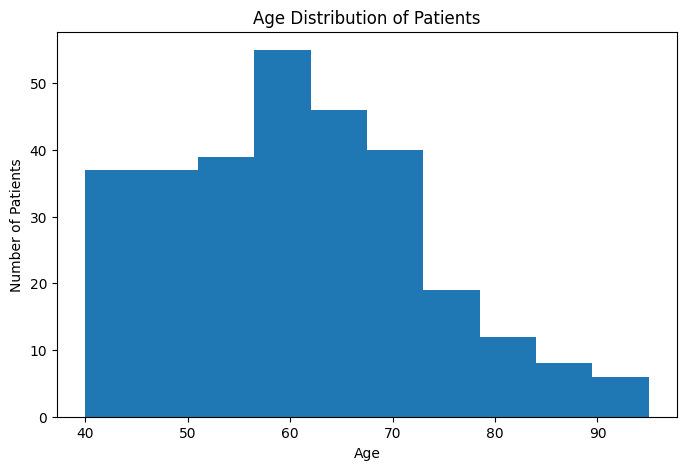

In [7]:
plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=10)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

## Gender Distribution Analysis

In [8]:
gender_counts = df["sex"].value_counts()

print(gender_counts)

sex
1    194
0    105
Name: count, dtype: int64


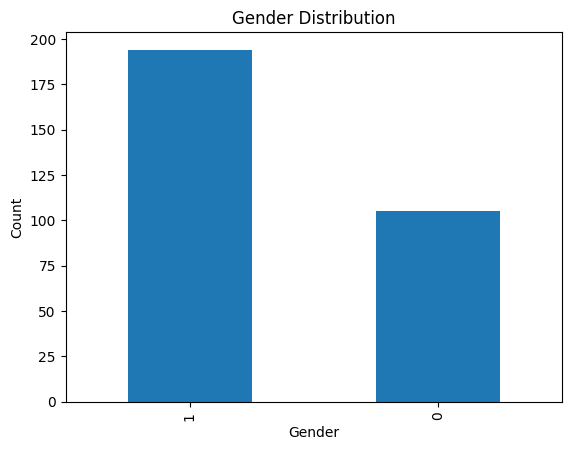

In [9]:
gender_counts.plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

In [10]:
gender_percentage = (
    df["sex"]
    .value_counts(normalize=True)
    * 100
)

print(gender_percentage)

sex
1    64.882943
0    35.117057
Name: proportion, dtype: float64


## Survival Analysis

The DEATH_EVENT variable indicates patient outcome.

- 0 = Survived
- 1 = Died

In [11]:
df["DEATH_EVENT"].value_counts()

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

In [12]:
survival_rate = (
    (df["DEATH_EVENT"] == 0).sum()
    / len(df)
) * 100

death_rate = (
    (df["DEATH_EVENT"] == 1).sum()
    / len(df)
) * 100

print("Survival Rate:", round(survival_rate,2), "%")
print("Death Rate:", round(death_rate,2), "%")

Survival Rate: 67.89 %
Death Rate: 32.11 %


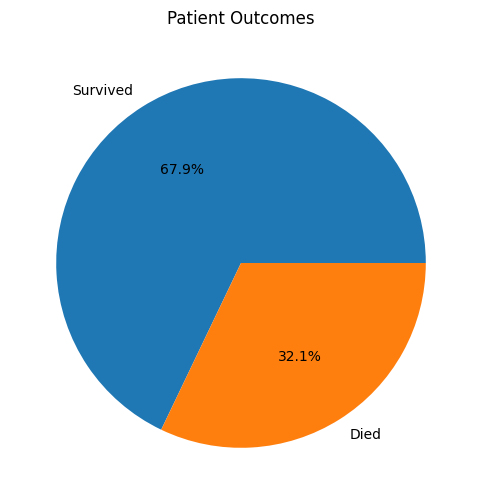

In [13]:
outcomes = df["DEATH_EVENT"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    outcomes,
    labels=["Survived","Died"],
    autopct="%1.1f%%"
)

plt.title("Patient Outcomes")

plt.show()

## Initial Findings

### Patient Demographics

- The dataset contains 299 heart failure patients.
- The average patient age is 60.83 years.
- Male patients account for 64.88% of the cohort.
- Female patients account for 35.12% of the cohort.

### Patient Outcomes

- 67.89% of patients survived during the follow-up period.
- 32.11% of patients experienced a death event.
- The dataset exhibits a moderate mortality rate, making it suitable for outcome and risk factor analysis.

## Risk Factor Analysis

This section compares clinical characteristics between survivors and non-survivors to identify potential risk factors associated with mortality.

In [14]:
df.groupby("DEATH_EVENT")["age"].mean()

DEATH_EVENT
0    58.761906
1    65.215281
Name: age, dtype: float64

In [15]:
pd.crosstab(
    df["diabetes"],
    df["DEATH_EVENT"],
    margins=True
)

DEATH_EVENT,0,1,All
diabetes,,,
0,118,56,174
1,85,40,125
All,203,96,299


In [16]:
pd.crosstab(
    df["anaemia"],
    df["DEATH_EVENT"],
    margins=True
)

DEATH_EVENT,0,1,All
anaemia,,,
0,120,50,170
1,83,46,129
All,203,96,299


In [17]:
pd.crosstab(
    df["high_blood_pressure"],
    df["DEATH_EVENT"],
    margins=True
)

DEATH_EVENT,0,1,All
high_blood_pressure,,,
0,137,57,194
1,66,39,105
All,203,96,299


In [18]:
df.groupby("DEATH_EVENT")["serum_creatinine"].mean()

DEATH_EVENT
0    1.184877
1    1.835833
Name: serum_creatinine, dtype: float64

In [19]:
df.groupby("DEATH_EVENT")["ejection_fraction"].mean()

DEATH_EVENT
0    40.26601
1    33.46875
Name: ejection_fraction, dtype: float64

In [20]:
df.groupby("DEATH_EVENT")["platelets"].mean()

DEATH_EVENT
0    266657.489901
1    256381.044792
Name: platelets, dtype: float64

In [21]:
pd.crosstab(
    df["smoking"],
    df["DEATH_EVENT"],
    margins=True
)

DEATH_EVENT,0,1,All
smoking,,,
0,137,66,203
1,66,30,96
All,203,96,299


## Key Risk Factors Identified

### Age

Patients who experienced a death event were older on average (65.22 years) than survivors (58.76 years), suggesting age is an important predictor of mortality.

### Kidney Function

Non-survivors exhibited substantially higher serum creatinine levels (1.84) compared with survivors (1.18), indicating impaired kidney function is associated with poor outcomes.

### Cardiac Function

Patients who died had lower ejection fractions (33.47%) than survivors (40.27%), highlighting reduced cardiac pumping efficiency as a major risk factor.

### Other Clinical Factors

Anaemia and high blood pressure showed moderate associations with mortality, while diabetes and smoking displayed weaker relationships in this cohort.

## Correlation Analysis

Correlation analysis was performed to identify relationships between clinical variables and mortality outcomes.

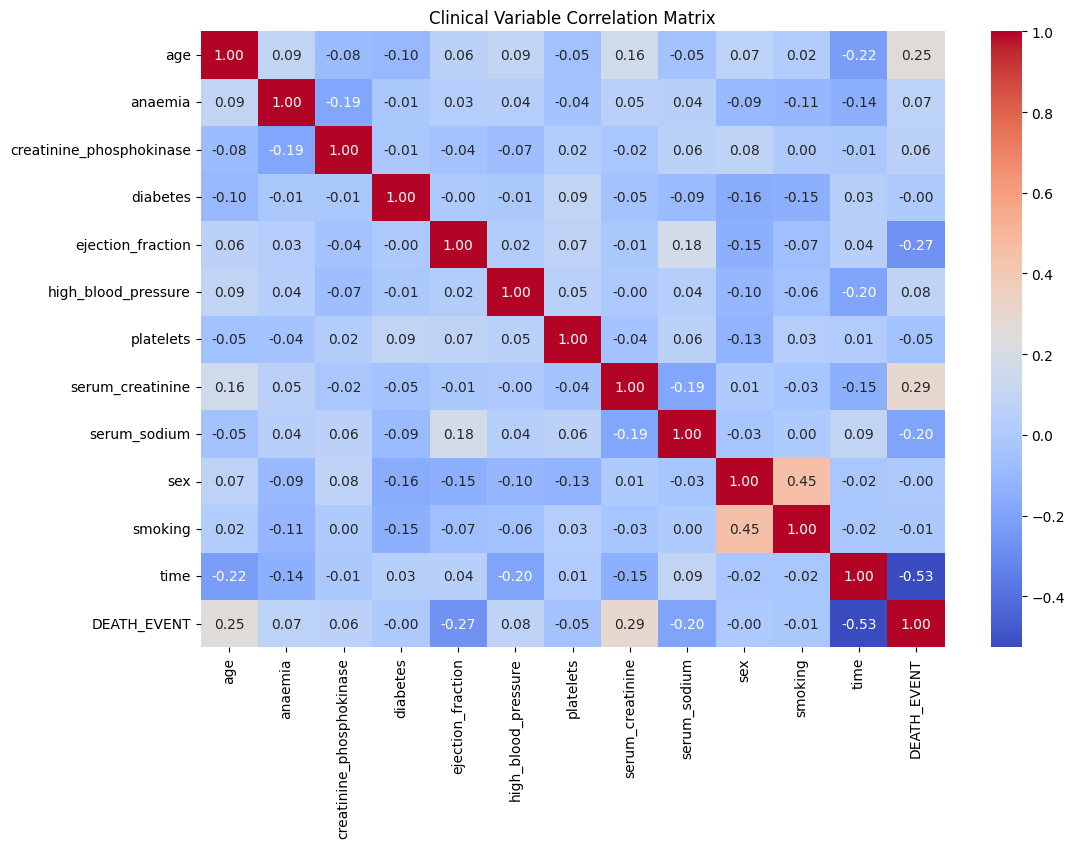

In [23]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Clinical Variable Correlation Matrix")

plt.show()

## Correlation Analysis Findings

The strongest factors associated with mortality were:

1. Follow-up Time (-0.53)
2. Serum Creatinine (+0.29)
3. Ejection Fraction (-0.27)
4. Age (+0.25)

Patients with elevated serum creatinine, reduced ejection fraction, and advanced age exhibited higher mortality rates.

These findings suggest that both cardiac function and kidney function play critical roles in determining patient outcomes.

<Figure size 800x500 with 0 Axes>

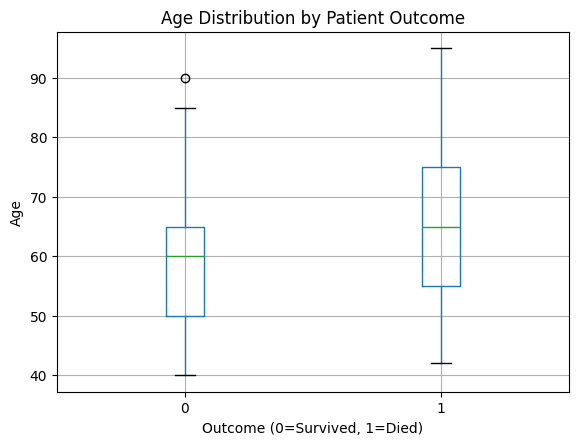

In [28]:
plt.figure(figsize=(8,5))

df.boxplot(
    column="age",
    by="DEATH_EVENT"
)

plt.title("Age Distribution by Patient Outcome")
plt.suptitle("")
plt.xlabel("Outcome (0=Survived, 1=Died)")
plt.ylabel("Age")

plt.savefig("../IMAGES/age_distribution_by_outcome.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

<Figure size 800x500 with 0 Axes>

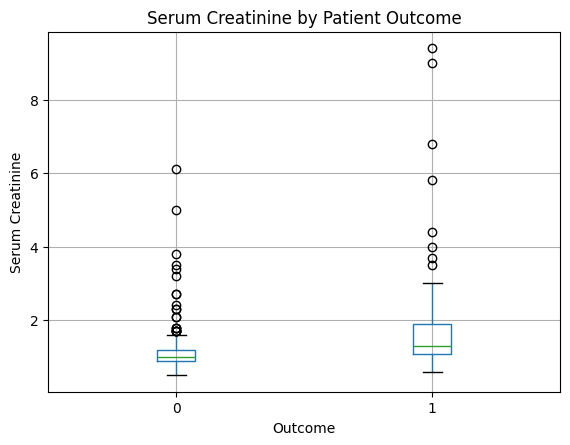

In [29]:
plt.figure(figsize=(8,5))

df.boxplot(
    column="serum_creatinine",
    by="DEATH_EVENT"
)

plt.title("Serum Creatinine by Patient Outcome")
plt.suptitle("")
plt.xlabel("Outcome")
plt.ylabel("Serum Creatinine")

plt.savefig(
    "../IMAGES/serum_creatinine_vs_outcome.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

<Figure size 800x500 with 0 Axes>

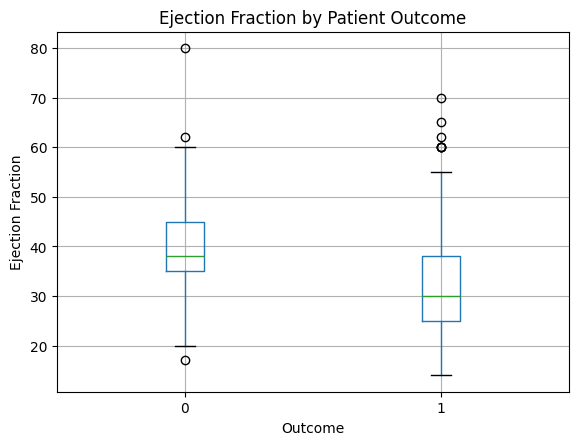

In [30]:
plt.figure(figsize=(8,5))

df.boxplot(
    column="ejection_fraction",
    by="DEATH_EVENT"
)

plt.title("Ejection Fraction by Patient Outcome")
plt.suptitle("")
plt.xlabel("Outcome")
plt.ylabel("Ejection Fraction")

plt.savefig(
    "../IMAGES/ejection_fraction_vs_outcome.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

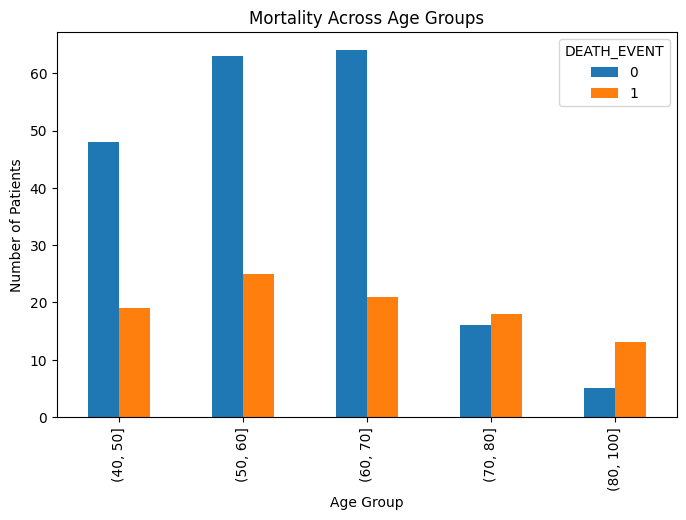

In [31]:
df["Age_Group"] = pd.cut(
    df["age"],
    bins=[40,50,60,70,80,100]
)

pd.crosstab(
    df["Age_Group"],
    df["DEATH_EVENT"]
).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Mortality Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")

plt.savefig(
    "../IMAGES/mortality_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
df["Age_Group"] = pd.cut(
    df["age"],
    bins=[40,50,60,70,80,100],
    labels=[
        "40-50",
        "50-60",
        "60-70",
        "70-80",
        "80+"
    ]
)

In [33]:
df["Outcome"] = df["DEATH_EVENT"].map(
    {
        0:"Survived",
        1:"Died"
    }
)

In [34]:
df["Gender"] = df["sex"].map(
    {
        0:"Female",
        1:"Male"
    }
)

In [35]:
df.to_csv(
    "../DATA/clinical_trial_processed.csv",
    index=False
)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!
